# US-05 - WAE-GAN para Deteccao de Anomalias

**Objetivo:** Treinar a variante `WAEGAN` sobre as janelas normais (`P1`) e avaliar deteccao de anomalias no conjunto de teste completo.

**Comparacao justa com os demais modelos:** este notebook executa **20 treinos independentes** com o mesmo conjunto fixo de seeds usado em GAT/Transformer (`42..61`).

**Entradas:** `data/processed/X_*.npy`, `y_*.npy` gerados no notebook de preprocessing.

**Convencao:** `0 = normal (P1)` e `1 = anomalia (P2/P3/P4)`.

## 1. Setup e Seeds

In [11]:
# ── Instalar PyTorch Geometric no Colab ───────────────────────────────────
# Colab não tem PyG por padrão. Esta célula instala apenas quando necessário.
import importlib

if not importlib.util.find_spec("torch_geometric"):
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "torch-geometric"], check=True)
    print("PyTorch Geometric installed.")
else:
    print("PyTorch Geometric already available.")

PyTorch Geometric already available.


In [12]:
import os
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
)

# -- Environment detection (local vs Google Colab) --------------------------------
IN_COLAB = "google.colab" in sys.modules or os.path.exists("/content")

if IN_COLAB:
    COLAB_REPO = Path("/content/anomaly_detection_models_comparison")
    if not COLAB_REPO.exists():
        os.system(
            "git clone https://github.com/camara0729/anomaly_detection_models_comparison.git "
            "/content/anomaly_detection_models_comparison"
        )
    PROJECT_ROOT = COLAB_REPO
else:
    PROJECT_ROOT = Path.cwd().resolve().parent if (Path.cwd().name == "notebooks") else Path.cwd().resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.evaluation import compute_anomaly_metrics
from src.models.wae_gan import WAEGAN, WAEGANConfig
from src.models.wae_gan_diagnoser import WAEGAN_FaultDiagnoser, FaultDiagnoserConfig
from src.preprocessing import make_waegan_anomaly_splits, to_sequence_last

# -- Seeds -------------------------------------------------------------------------
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# -- Device ------------------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"Project root: {PROJECT_ROOT}")

Device: cuda
  GPU: Tesla T4
  VRAM: 15.6 GB
Project root: /content/anomaly_detection_models_comparison


## 2. Carregar Dados

In [13]:
# -- Localizacao automatica de data/processed no Google Drive ----------------------
FOLDER_ID = "1iLHFoAN4NK4gOVJHa07nxJMCz10dChJt"
REQUIRED_PROCESSED_FILES = {
    "scaler.pkl",
    "split_config.json",
    "X_train.npy", "X_val.npy", "X_test.npy",
    "y_train.npy", "y_val.npy", "y_test.npy",
}

def is_valid_processed_dir(path: Path) -> bool:
    if not path.exists() or not path.is_dir():
        return False
    file_names = {p.name for p in path.iterdir() if p.is_file()}
    return REQUIRED_PROCESSED_FILES.issubset(file_names)

def find_processed_dir_in_drive() -> Path:
    candidates = [
        Path(f"/content/drive/MyDrive/.shortcut-targets-by-id/{FOLDER_ID}/data/processed"),
        Path("/content/drive/MyDrive/anomaly_detection_models_comparison/data/processed"),
        Path("/content/drive/MyDrive/anomaly_detection_comparison/data/processed"),
        Path("/content/drive/Shareddrives/anomaly_detection_models_comparison/data/processed"),
    ]
    for c in candidates:
        if is_valid_processed_dir(c):
            return c

    roots = [Path("/content/drive/MyDrive"), Path("/content/drive/Shareddrives")]
    for root in roots:
        if not root.exists():
            continue
        for split_file in root.rglob("split_config.json"):
            processed_dir = split_file.parent
            if is_valid_processed_dir(processed_dir):
                return processed_dir

    raise FileNotFoundError(
        "Nao foi possivel localizar data/processed com os arquivos esperados no Drive."
    )

if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive", force_remount=False)
    DRIVE_PROCESSED_DIR = find_processed_dir_in_drive()
    DRIVE_PROJECT_DIR = DRIVE_PROCESSED_DIR.parent.parent
    DATA_DIR = DRIVE_PROCESSED_DIR
    print(f"Drive data/processed: {DRIVE_PROCESSED_DIR}")
else:
    DRIVE_PROCESSED_DIR = None
    DRIVE_PROJECT_DIR = None
    DATA_DIR = PROJECT_ROOT / "data" / "processed"
    if not is_valid_processed_dir(DATA_DIR):
        raise FileNotFoundError(
            f"Diretorio invalido: {DATA_DIR}. Verifique se os arquivos de data/processed existem."
        )
    print(f"Local data/processed: {DATA_DIR}")

ARTIFACTS_ROOT = DRIVE_PROJECT_DIR if DRIVE_PROJECT_DIR is not None else PROJECT_ROOT
MODELS_DIR = ARTIFACTS_ROOT / "models"
FIGURES_DIR = ARTIFACTS_ROOT / "docs" / "figures"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Arquivos encontrados:")
for fname in sorted(REQUIRED_PROCESSED_FILES):
    print(f"  - {fname}")

X_train = np.load(DATA_DIR / "X_train.npy")
y_train = np.load(DATA_DIR / "y_train.npy")
X_val = np.load(DATA_DIR / "X_val.npy")
y_val = np.load(DATA_DIR / "y_val.npy")
X_test = np.load(DATA_DIR / "X_test.npy")
y_test = np.load(DATA_DIR / "y_test.npy")
print('X_train:', X_train.shape, 'y_train:', y_train.shape)
print('X_val:  ', X_val.shape, 'y_val:  ', y_val.shape)
print('X_test: ', X_test.shape, 'y_test: ', y_test.shape)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive data/processed: /content/drive/MyDrive/anomaly_detection_comparison/data/processed
Arquivos encontrados:
  - X_test.npy
  - X_train.npy
  - X_val.npy
  - scaler.pkl
  - split_config.json
  - y_test.npy
  - y_train.npy
  - y_val.npy
X_train: (9720, 9, 4096) y_train: (9720,)
X_val:   (1944, 9, 4096) y_val:   (1944,)
X_test:  (2916, 9, 4096) y_test:  (2916,)


## 3. Hiperparametros

In [14]:
NORMAL_LABEL = 0

# Configuracao escolhida a partir do grid search
EMBEDDING_DIM = 64
ENCODER_LAYERS = 2
DROPOUT = 0.0
TCN_HIDDEN = 64
TCN_KERNEL = 3
DISC_HIDDEN = 16
DISC_LAYERS = 2
WAE_REG = 5.0
SIGMA_Z = 1.0

# Treino
LR = 1e-3
DISC_LR = 1e-4
DISC_STEPS = 1
BATCH_SIZE = 64
EPOCHS = 50
PATIENCE = 5
MIN_DELTA = 0.0

# Avaliacao
THRESHOLD_MULTIPLIER = 1.5

# Multi-run setup (padronizado com GAT/Transformer)
NUM_RUNS = 20
RUN_SEEDS = list(range(42, 42 + NUM_RUNS))  # 42..61
assert len(RUN_SEEDS) == NUM_RUNS

from datetime import datetime

def make_unique_runset_dir(root_dir: Path, prefix: str = "runset") -> Path:
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    candidate = root_dir / f"{prefix}_{timestamp}"
    suffix = 1
    while candidate.exists():
        candidate = root_dir / f"{prefix}_{timestamp}_{suffix:02d}"
        suffix += 1
    candidate.mkdir(parents=True, exist_ok=False)
    return candidate

RUNS_ROOT_DIR = MODELS_DIR / "wae_gan_runs_20"
RUNS_ROOT_DIR.mkdir(parents=True, exist_ok=True)

RUNS_MODELS_DIR = make_unique_runset_dir(RUNS_ROOT_DIR)
RUN_RESULTS_PATH = RUNS_MODELS_DIR / "wae_gan_runs_summary.csv"

print('EMBEDDING_DIM =', EMBEDDING_DIM)
print('ENCODER_LAYERS =', ENCODER_LAYERS)
print('TCN_HIDDEN =', TCN_HIDDEN)
print('TCN_KERNEL =', TCN_KERNEL)
print('DISC_HIDDEN =', DISC_HIDDEN)
print('DISC_LAYERS =', DISC_LAYERS)
print('WAE_REG =', WAE_REG)
print('SIGMA_Z =', SIGMA_Z)
print('LR =', LR)
print('DISC_LR =', DISC_LR)
print('BATCH_SIZE =', BATCH_SIZE)
print('EPOCHS =', EPOCHS)
print('PATIENCE =', PATIENCE)
print(f'Runs: {NUM_RUNS} with fixed seeds {RUN_SEEDS[0]}..{RUN_SEEDS[-1]}')
print('Runs root dir:', RUNS_ROOT_DIR)
print('Active runset dir:', RUNS_MODELS_DIR)

EMBEDDING_DIM = 64
ENCODER_LAYERS = 2
TCN_HIDDEN = 64
TCN_KERNEL = 3
DISC_HIDDEN = 16
DISC_LAYERS = 2
WAE_REG = 5.0
SIGMA_Z = 1.0
LR = 0.001
DISC_LR = 0.0001
BATCH_SIZE = 64
EPOCHS = 50
PATIENCE = 5
Runs: 20 with fixed seeds 42..61
Runs root dir: /content/drive/MyDrive/anomaly_detection_comparison/models/wae_gan_runs_20
Active runset dir: /content/drive/MyDrive/anomaly_detection_comparison/models/wae_gan_runs_20/runset_20260415_203901


## 4. Preparacao dos Splits de Anomalia

In [15]:
CLASS_NAMES = ['Normal (P1)', 'Fault A (P2)', 'Fault B (P3)', 'Fault C (P4)']
FAULT_LABELS = [1, 2, 3]
CLASSIFIER_TYPE = 'xgboost'
N_ESTIMATORS = 300
THRESHOLD_MULT = THRESHOLD_MULTIPLIER

def make_data_by_label(X_seq: np.ndarray, y: np.ndarray) -> dict[int, np.ndarray]:
    return {int(lbl): X_seq[y == lbl] for lbl in np.unique(y)}

splits = make_waegan_anomaly_splits(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    normal_label=NORMAL_LABEL,
)

X_train_normal = splits['X_train_normal']
X_val_normal = splits['X_val_normal']
X_test_seq = splits['X_test']
y_test_binary = splits['y_test_binary']
y_test_multi = splits['y_test_multiclass']

X_train_seq = to_sequence_last(X_train)
train_by_label = make_data_by_label(X_train_seq, y_train)
test_by_label = make_data_by_label(X_test_seq, y_test_multi)

print('X_train_normal:', X_train_normal.shape)
print('X_val_normal:  ', X_val_normal.shape)
print('X_test_seq:    ', X_test_seq.shape)
print('Anomalies in test:', int(y_test_binary.sum()), 'of', len(y_test_binary))
print('Train splits per class (sequence-last):')
for lbl, arr in train_by_label.items():
    print(f"  [{lbl}] {CLASS_NAMES[lbl]}: {arr.shape}")

X_train_normal: (2430, 4096, 9)
X_val_normal:   (486, 4096, 9)
X_test_seq:     (2916, 4096, 9)
Anomalies in test: 2187 of 2916
Train splits per class (sequence-last):
  [0] Normal (P1): (2430, 4096, 9)
  [1] Fault A (P2): (2430, 4096, 9)
  [2] Fault B (P3): (2430, 4096, 9)
  [3] Fault C (P4): (2430, 4096, 9)


## 5. Modelo

In [16]:
def set_all_seeds(seed: int) -> None:
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def build_waegan_config() -> WAEGANConfig:
    return WAEGANConfig(
        n_features=X_train_normal.shape[2],
        embedding_dim=EMBEDDING_DIM,
        encoder_layers=ENCODER_LAYERS,
        dropout=DROPOUT,
        tcn_hidden=TCN_HIDDEN,
        tcn_kernel=TCN_KERNEL,
        disc_hidden=DISC_HIDDEN,
        disc_layers=DISC_LAYERS,
        lr=LR,
        disc_lr=DISC_LR,
        wae_regularization_term=WAE_REG,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        disc_steps=DISC_STEPS,
        sigma_z=SIGMA_Z,
        early_stopping_patience=PATIENCE,
        early_stopping_min_delta=MIN_DELTA,
        restore_best_weights=True,
        device=str(DEVICE),
        adversarial_loss="cross_entropy",
    )

def build_waegan_model(seed: int) -> WAEGAN:
    set_all_seeds(seed)
    return WAEGAN(build_waegan_config())

def compute_multiclass_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    *,
    labels: list[int],
    prefix: str,
) -> dict[str, float]:
    return {
        f'{prefix}_accuracy': float(accuracy_score(y_true, y_pred)),
        f'{prefix}_precision_macro': float(precision_score(y_true, y_pred, labels=labels, average='macro', zero_division=0)),
        f'{prefix}_recall_macro': float(recall_score(y_true, y_pred, labels=labels, average='macro', zero_division=0)),
        f'{prefix}_f1_macro': float(f1_score(y_true, y_pred, labels=labels, average='macro', zero_division=0)),
    }

def empty_multiclass_metrics(prefix: str) -> dict[str, float]:
    return {
        f'{prefix}_accuracy': float('nan'),
        f'{prefix}_precision_macro': float('nan'),
        f'{prefix}_recall_macro': float('nan'),
        f'{prefix}_f1_macro': float('nan'),
    }

def evaluate_paired_waegan_xgboost(model: WAEGAN, run_idx: int, run_seed: int) -> dict[str, float | str]:
    train_scores = model.predict_anomaly_score(data=X_train_normal)
    test_scores = model.predict_anomaly_score(data=X_test_seq)
    threshold = model.calculate_threshold(train_scores, multiplier=THRESHOLD_MULT)

    anomaly_metrics = compute_anomaly_metrics(y_test_binary, test_scores, threshold=threshold)
    anomaly_metrics = {
        f'anomaly_{k}': float(v)
        for k, v in anomaly_metrics.items()
        if k != 'threshold'
    }

    diagnoser_path = RUNS_MODELS_DIR / f'wae_gan_xgboost_diagnoser_run_{run_idx:02d}.pkl'
    diagnoser = WAEGAN_FaultDiagnoser(
        waegan=model,
        config=FaultDiagnoserConfig(
            classifier=CLASSIFIER_TYPE,
            n_estimators=N_ESTIMATORS,
            random_state=run_seed,
            class_names=CLASS_NAMES,
            anomaly_threshold=float(threshold),
        ),
    )

    t_fit = time.time()
    diagnoser.fit(
        data_by_label=train_by_label,
        normal_label=NORMAL_LABEL,
        threshold_multiplier=THRESHOLD_MULT,
        verbose=False,
    )
    xgb_fit_seconds = time.time() - t_fit

    t_pred = time.time()
    diag_results = diagnoser.predict(X_test_seq)
    xgb_predict_seconds = time.time() - t_pred

    diag_is_anomaly = diag_results['is_anomaly']
    diag_fault_label = diag_results['fault_label']
    y_true_flagged = y_test_multi[diag_is_anomaly]
    y_pred_flagged = diag_fault_label[diag_is_anomaly]

    if len(y_true_flagged) > 0:
        stage2_metrics = compute_multiclass_metrics(
            y_true_flagged,
            y_pred_flagged,
            labels=FAULT_LABELS,
            prefix='stage2',
        )
    else:
        stage2_metrics = empty_multiclass_metrics('stage2')

    y_pred_full = diag_fault_label.copy()
    y_pred_full[diag_fault_label == -1] = NORMAL_LABEL
    e2e_metrics = compute_multiclass_metrics(
        y_test_multi,
        y_pred_full,
        labels=list(range(len(CLASS_NAMES))),
        prefix='e2e',
    )

    diagnoser.save(path=diagnoser_path, waegan_path=None)

    return {
        'anomaly_threshold': float(threshold),
        'xgb_fit_seconds': float(xgb_fit_seconds),
        'xgb_predict_seconds': float(xgb_predict_seconds),
        'flagged_ratio': float(diag_is_anomaly.mean()),
        'n_flagged': int(diag_is_anomaly.sum()),
        'diagnoser_path': str(diagnoser_path),
        **anomaly_metrics,
        **stage2_metrics,
        **e2e_metrics,
    }

probe_model = build_waegan_model(RUN_SEEDS[0])
n_params = sum(p.numel() for p in probe_model.model.parameters() if p.requires_grad)
print(probe_model.model)
print('\nTrainable parameters:', f'{n_params:,}')

WAEGANCore(
  (encoder): Encoder_TCN(
    (tcn_layers): ModuleList(
      (0): TemporalBlock(
        (conv1): Conv1d(9, 64, kernel_size=(3,), stride=(1,), padding=(2,))
        (batch_norm1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU()
        (dropout): Dropout(p=0.0, inplace=False)
        (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,))
        (batch_norm2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (downsample): Conv1d(9, 64, kernel_size=(1,), stride=(1,))
      )
      (1): TemporalBlock(
        (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
        (batch_norm1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU()
        (dropout): Dropout(p=0.0, inplace=False)
        (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
        (batch_

## 6. Treinar WAE-GAN 20 Vezes (Seeds Fixas)

In [17]:
all_run_histories = {}
run_results = []

for run_idx, run_seed in enumerate(RUN_SEEDS, start=1):
    print(f"[Run {run_idx:02d}/{NUM_RUNS}] seed={run_seed}")

    model = build_waegan_model(run_seed)
    t_start = time.time()
    model.fit(train_data=X_train_normal, validation_data=X_val_normal, verbose=True)
    train_time_s = time.time() - t_start

    checkpoint_path = RUNS_MODELS_DIR / f'wae_gan_run_{run_idx:02d}.pt'
    model.save(checkpoint_path)

    best_monitor = float(model.best_monitor_value_) if model.best_monitor_value_ is not None else float('inf')
    best_epoch = int(model.best_epoch_) if model.best_epoch_ is not None else -1
    stopped_epoch = int(model.stopped_epoch_) if model.stopped_epoch_ is not None else -1

    paired_metrics = evaluate_paired_waegan_xgboost(model, run_idx, run_seed)

    run_results.append({
        'run': run_idx,
        'seed': run_seed,
        'best_epoch': best_epoch,
        'best_monitor': best_monitor,
        'stopped_epoch': stopped_epoch,
        'train_seconds': float(train_time_s),
        'model_path': str(checkpoint_path),
        **paired_metrics,
    })
    all_run_histories[run_idx] = model.history_

    print(
        f"  best_epoch={best_epoch}, best_monitor={best_monitor:.6f}, stopped_epoch={stopped_epoch}, "
        f"train_time={train_time_s:.1f}s, anomaly_f1={paired_metrics['anomaly_f1']:.4f}, "
        f"e2e_f1_macro={paired_metrics['e2e_f1_macro']:.4f}"
    )

results_df = pd.DataFrame(run_results).sort_values('run').reset_index(drop=True)
results_df.to_csv(RUN_RESULTS_PATH, index=False)

best_row = results_df.sort_values('best_monitor', ascending=True).iloc[0]
BEST_RUN = int(best_row['run'])
BEST_SEED = int(best_row['seed'])
CHECKPOINT_PATH = Path(best_row['model_path'])
history = all_run_histories[BEST_RUN]

run_model_files = sorted(RUNS_MODELS_DIR.glob('wae_gan_run_*.pt'))
assert len(run_model_files) == NUM_RUNS, (
    f'Esperados {NUM_RUNS} modelos, encontrados {len(run_model_files)}'
 )

print('\nResumo das 20 execucoes pareadas:')
print(results_df[[
    'run', 'seed', 'best_epoch', 'best_monitor', 'anomaly_f1', 'stage2_f1_macro', 'e2e_f1_macro', 'train_seconds', 'xgb_fit_seconds'
]].to_string(index=False))
print(f'\nMelhor run WAE-GAN: {BEST_RUN:02d} (seed={BEST_SEED})')
print(f"Melhor monitor: {best_row['best_monitor']:.6f}")
print(f'Checkpoint selecionado para avaliacao detalhada: {CHECKPOINT_PATH}')
print(f'Resumo completo salvo em: {RUN_RESULTS_PATH}')
print(f'Pasta final dos 20 modelos/diagnosers: {RUNS_MODELS_DIR}')

[Run 01/20] seed=42
Epoch 1/50 | loss_D=1.512296 | loss_G=3.859916 | val_G=3.231478
Epoch 2/50 | loss_D=1.594966 | loss_G=3.090860 | val_G=3.067105
Epoch 3/50 | loss_D=1.562801 | loss_G=3.099823 | val_G=3.174963
Epoch 4/50 | loss_D=1.516112 | loss_G=3.252349 | val_G=3.353193
Epoch 5/50 | loss_D=1.470884 | loss_G=3.423128 | val_G=3.494587
Epoch 6/50 | loss_D=1.444721 | loss_G=3.495740 | val_G=3.506329
Epoch 7/50 | loss_D=1.428243 | loss_G=3.506454 | val_G=3.522370
Early stopping at epoch 7 (best_epoch=2, best_monitor=3.067105).


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:40:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  best_epoch=2, best_monitor=3.067105, stopped_epoch=7, train_time=69.8s, anomaly_f1=0.9977, e2e_f1_macro=0.9525
[Run 02/20] seed=43


/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Epoch 1/50 | loss_D=1.450896 | loss_G=3.635814 | val_G=3.302729
Epoch 2/50 | loss_D=1.474221 | loss_G=3.242343 | val_G=3.225890
Epoch 3/50 | loss_D=1.454760 | loss_G=3.249072 | val_G=3.286083
Epoch 4/50 | loss_D=1.429542 | loss_G=3.320828 | val_G=3.352920
Epoch 5/50 | loss_D=1.409638 | loss_G=3.370759 | val_G=3.394859
Epoch 6/50 | loss_D=1.392972 | loss_G=3.417322 | val_G=3.428504
Epoch 7/50 | loss_D=1.389930 | loss_G=3.407555 | val_G=3.413351
Early stopping at epoch 7 (best_epoch=2, best_monitor=3.225890).


...

  best_epoch=2, best_monitor=2.208135, stopped_epoch=7, train_time=69.3s, anomaly_f1=0.9961, e2e_f1_macro=0.9505
[Run 20/20] seed=61


/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Epoch 1/50 | loss_D=1.530836 | loss_G=2.865904 | val_G=2.496839
Epoch 2/50 | loss_D=1.570679 | loss_G=2.466765 | val_G=2.476277
Epoch 3/50 | loss_D=1.526821 | loss_G=2.524961 | val_G=2.583630
Epoch 4/50 | loss_D=1.479625 | loss_G=2.653350 | val_G=2.723096
Epoch 5/50 | loss_D=1.440288 | loss_G=2.779025 | val_G=2.833409
Epoch 6/50 | loss_D=1.410520 | loss_G=2.888996 | val_G=2.926615
Epoch 7/50 | loss_D=1.409593 | loss_G=2.908070 | val_G=2.927431
Early stopping at epoch 7 (best_epoch=2, best_monitor=2.476277).


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:12:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  best_epoch=2, best_monitor=2.476277, stopped_epoch=7, train_time=69.0s, anomaly_f1=0.9966, e2e_f1_macro=0.9573

Resumo das 20 execucoes pareadas:
 run  seed  best_epoch  best_monitor  anomaly_f1  stage2_f1_macro  e2e_f1_macro  train_seconds  xgb_fit_seconds
   1    42           2      3.067105    0.997719         0.940928      0.952476      69.844343         8.207517
   2    43           2      3.225890    0.995448         0.924341      0.941553      69.298633         7.864711
   3    44           2      2.915382    0.996582         0.942758      0.952688      69.249097         7.853845
   4    45           2      2.378044    0.997037         0.904564      0.926887      69.036894         7.529885
   5    46           2      3.163025    0.997719         0.909758      0.930952      69.158090         7.359094
   6    47          31      3.127862    0.392359         0.931779      0.387288     355.943865         9.122494
   7    48           2      3.336831    0.996809         0.953931   

## 7. Curvas de Treinamento (Melhor Run)

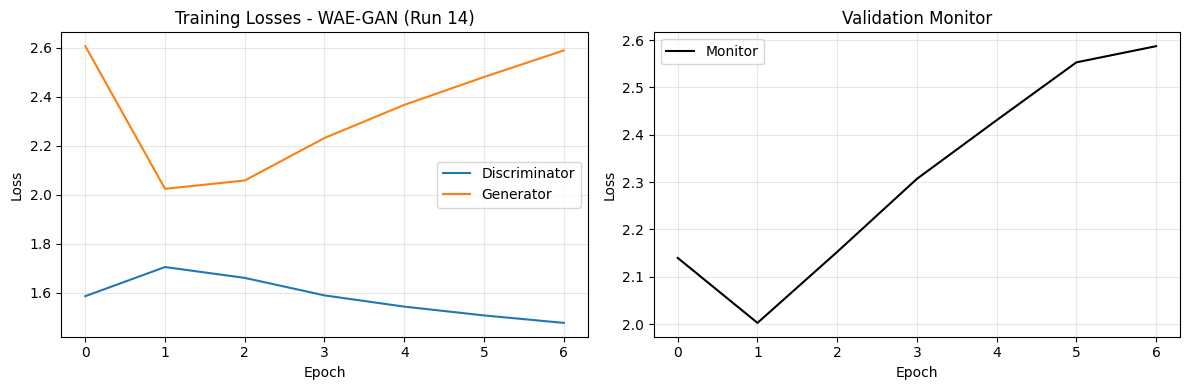

Saved: docs/figures/05_wae_gan_training_curves_run_14.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['discriminator'], label='Discriminator')
axes[0].plot(history['generator'], label='Generator')
axes[0].set_title(f'Training Losses - WAE-GAN (Run {BEST_RUN:02d})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['monitor'], color='black', label='Monitor')
axes[1].set_title('Validation Monitor')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_path = FIGURES_DIR / f'05_wae_gan_training_curves_run_{BEST_RUN:02d}.png'
fig.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', save_path.relative_to(ARTIFACTS_ROOT))

## 8. Avaliacao no Conjunto de Teste (Melhor Run)

In [19]:
print(f"Avaliando melhor run: {BEST_RUN:02d} (checkpoint: {CHECKPOINT_PATH.name})")
best_model = WAEGAN.load(CHECKPOINT_PATH, map_location=str(DEVICE))

train_scores = best_model.predict_anomaly_score(data=X_train_normal)
val_scores = best_model.predict_anomaly_score(data=X_val_normal)
test_scores = best_model.predict_anomaly_score(data=X_test_seq)

threshold = best_model.calculate_threshold(train_scores, multiplier=THRESHOLD_MULTIPLIER)
metrics = compute_anomaly_metrics(y_test_binary, test_scores, threshold=threshold)

print('Threshold:', threshold)
display(pd.Series(metrics).to_frame('value'))

Avaliando melhor run: 14 (checkpoint: wae_gan_run_14.pt)


/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Threshold: 0.14812103658914566


,value
auc_roc,1.000000
average_precision,1.000000
threshold,0.148121
accuracy,0.993827
precision,0.991837
recall,1.000000
f1,0.995902
tn,711.000000
fp,18.000000
fn,0.000000


As metricas acima correspondem ao melhor run do WAE-GAN. A agregacao robusta dos 20 runs pareados `WAE-GAN + XGBoost` aparece na secao 10.

## 9. Curva ROC e Distribuicao de Scores

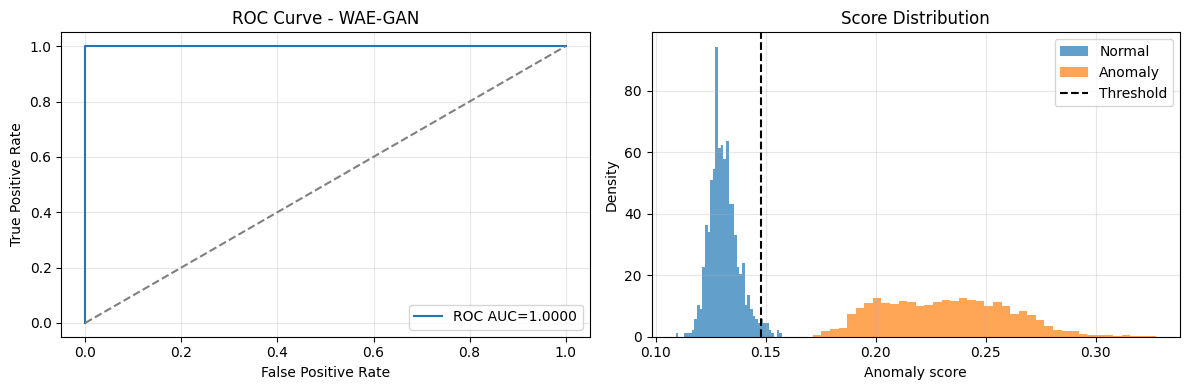

Saved: docs/figures/07_wae_gan_scores.png


In [20]:
fpr, tpr, _ = roc_curve(y_test_binary, test_scores)
normal_scores = test_scores[y_test_binary == 0]
anomaly_scores = test_scores[y_test_binary == 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(fpr, tpr, label=f"ROC AUC={metrics['auc_roc']:.4f}")
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0].set_title('ROC Curve - WAE-GAN')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(normal_scores, bins=40, alpha=0.7, label='Normal', density=True)
axes[1].hist(anomaly_scores, bins=40, alpha=0.7, label='Anomaly', density=True)
axes[1].axvline(threshold, color='black', linestyle='--', label='Threshold')
axes[1].set_title('Score Distribution')
axes[1].set_xlabel('Anomaly score')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_path = FIGURES_DIR / '07_wae_gan_scores.png'
fig.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', save_path.relative_to(ARTIFACTS_ROOT))

## 10. WAE-GAN + XGBoost

O diagnoser `XGBoost` agora e treinado em cada um dos 20 runs pareados. Abaixo ficam a inspecao detalhada do melhor run e, em seguida, o resumo `mean +/- std` dos 20 experimentos.

In [21]:
DIAGNOSER_PATH = Path(results_df.loc[results_df['run'] == BEST_RUN, 'diagnoser_path'].iloc[0])
diagnoser = WAEGAN_FaultDiagnoser.load(
    path=DIAGNOSER_PATH,
    waegan=best_model,
)

print('Diagnoser loaded.')
print(f'  best_run      : {BEST_RUN:02d}')
print(f'  seed          : {BEST_SEED}')
print(f'  classifier    : {diagnoser.config.classifier}')
print(f'  n_estimators  : {diagnoser.config.n_estimators}')
print(f'  threshold     : {diagnoser.config.anomaly_threshold:.6f}')
print(f'  diagnoser_path: {DIAGNOSER_PATH.relative_to(ARTIFACTS_ROOT)}')

t_pred = time.time()
diag_results = diagnoser.predict(X_test_seq)
pred_time = time.time() - t_pred

diag_anomaly_scores = diag_results['anomaly_score']
diag_is_anomaly = diag_results['is_anomaly']
diag_fault_label = diag_results['fault_label']

print(f'Prediction time: {pred_time:.2f}s  ({pred_time / len(X_test_seq) * 1000:.3f} ms/sample)')
print('\nAnomaly detection (Stage 1):')
diag_anomaly_metrics = compute_anomaly_metrics(
    y_test_binary,
    diag_anomaly_scores,
    threshold=diagnoser.config.anomaly_threshold,
)
display(pd.Series(diag_anomaly_metrics).to_frame('value'))

flagged_mask = diag_is_anomaly
y_true_flagged = y_test_multi[flagged_mask]
y_pred_flagged = diag_fault_label[flagged_mask]

print('\nFault classification report (on anomaly-flagged windows):')
if len(y_true_flagged) == 0:
    print('No anomaly-flagged windows found on the test set.')
else:
    print(classification_report(
        y_true_flagged,
        y_pred_flagged,
        labels=FAULT_LABELS,
        target_names=[CLASS_NAMES[i] for i in FAULT_LABELS],
        zero_division=0,
    ))

y_pred_full = diag_fault_label.copy()
y_pred_full[diag_fault_label == -1] = NORMAL_LABEL

print('End-to-end multiclass classification report (all test windows):')
print(classification_report(
    y_test_multi,
    y_pred_full,
    labels=list(range(len(CLASS_NAMES))),
    target_names=CLASS_NAMES,
    zero_division=0,
))

Diagnoser loaded.
  best_run      : 14
  seed          : 55
  classifier    : xgboost
  n_estimators  : 300
  threshold     : 0.148121
  diagnoser_path: models/wae_gan_runs_20/runset_20260415_203901/wae_gan_xgboost_diagnoser_run_14.pkl
Prediction time: 3.36s  (1.151 ms/sample)

Anomaly detection (Stage 1):


,value
auc_roc,1.000000
average_precision,1.000000
threshold,0.148121
accuracy,0.993827
precision,0.991837
recall,1.000000
f1,0.995902
tn,711.000000
fp,18.000000
fn,0.000000



Fault classification report (on anomaly-flagged windows):
              precision    recall  f1-score   support

Fault A (P2)       0.96      0.94      0.95       729
Fault B (P3)       0.95      0.95      0.95       729
Fault C (P4)       0.98      1.00      0.99       729

   micro avg       0.97      0.96      0.96      2187
   macro avg       0.97      0.96      0.96      2187
weighted avg       0.97      0.96      0.96      2187

End-to-end multiclass classification report (all test windows):
              precision    recall  f1-score   support

 Normal (P1)       0.98      1.00      0.99       729
Fault A (P2)       0.96      0.94      0.95       729
Fault B (P3)       0.95      0.95      0.95       729
Fault C (P4)       0.98      1.00      0.99       729

    accuracy                           0.97      2916
   macro avg       0.97      0.97      0.97      2916
weighted avg       0.97      0.97      0.97      2916



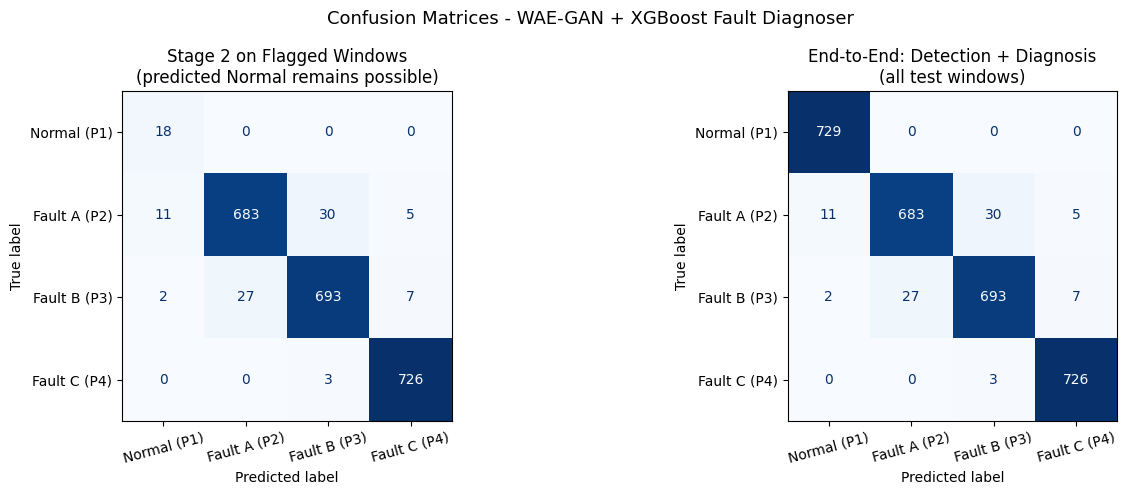

Saved: docs/figures/07_wae_gan_xgboost_confusion.png


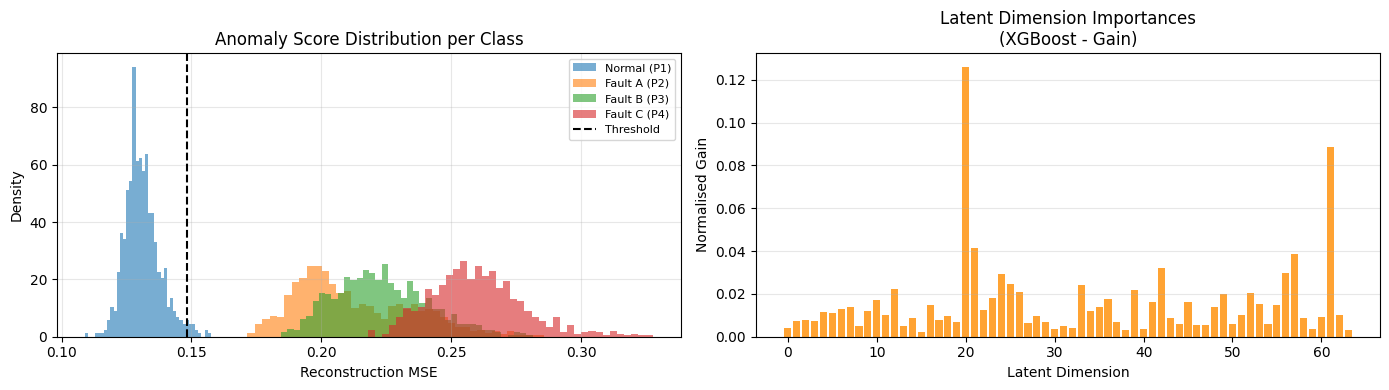

Saved: docs/figures/07_wae_gan_xgboost_analysis.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if len(y_true_flagged) == 0:
    axes[0].axis('off')
    axes[0].text(0.5, 0.5, 'No anomaly-flagged windows', ha='center', va='center')
else:
    cm_stage2 = confusion_matrix(
        y_true_flagged,
        y_pred_flagged,
        labels=list(range(len(CLASS_NAMES))),
    )
    ConfusionMatrixDisplay(
        cm_stage2,
        display_labels=CLASS_NAMES,
    ).plot(ax=axes[0], colorbar=False, cmap='Blues')
    axes[0].tick_params(axis='x', rotation=15)
axes[0].set_title('Stage 2 on Flagged Windows\n(predicted Normal remains possible)')

cm_full = confusion_matrix(y_test_multi, y_pred_full, labels=list(range(len(CLASS_NAMES))))
ConfusionMatrixDisplay(cm_full, display_labels=CLASS_NAMES).plot(
    ax=axes[1], colorbar=False, cmap='Blues'
)
axes[1].set_title('End-to-End: Detection + Diagnosis\n(all test windows)')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Confusion Matrices - WAE-GAN + XGBoost Fault Diagnoser', fontsize=13)
plt.tight_layout()
save_path = FIGURES_DIR / '07_wae_gan_xgboost_confusion.png'
fig.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', save_path.relative_to(ARTIFACTS_ROOT))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for lbl in sorted(test_by_label):
    mask = y_test_multi == lbl
    axes[0].hist(
        diag_anomaly_scores[mask], bins=40, alpha=0.6,
        label=CLASS_NAMES[lbl], density=True,
    )
axes[0].axvline(
    diagnoser.config.anomaly_threshold,
    color='black', linestyle='--', linewidth=1.5, label='Threshold'
)
axes[0].set_title('Anomaly Score Distribution per Class')
axes[0].set_xlabel('Reconstruction MSE')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

if hasattr(diagnoser.classifier_, 'get_booster'):
    booster = diagnoser.classifier_.get_booster()
    scores = booster.get_score(importance_type='gain')
    emb_dim = best_model.config.embedding_dim
    importances = np.array([scores.get(f'f{i}', 0.0) for i in range(emb_dim)])
    if importances.sum() > 0:
        importances = importances / importances.sum()
    axes[1].bar(range(emb_dim), importances, color='darkorange', alpha=0.8)
    axes[1].set_title('Latent Dimension Importances\n(XGBoost - Gain)')
    axes[1].set_xlabel('Latent Dimension')
    axes[1].set_ylabel('Normalised Gain')
    axes[1].grid(True, alpha=0.3, axis='y')
else:
    axes[1].axis('off')
    axes[1].text(0.5, 0.5, 'Feature importances not available', ha='center', va='center')

plt.tight_layout()
save_path = FIGURES_DIR / '07_wae_gan_xgboost_analysis.png'
fig.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', save_path.relative_to(ARTIFACTS_ROOT))

### 10.1 Mean +/- Std dos 20 Runs

In [23]:
ARTICLE_METRICS = [
    'anomaly_auc_roc',
    'anomaly_average_precision',
    'anomaly_accuracy',
    'anomaly_precision',
    'anomaly_recall',
    'anomaly_f1',
    'stage2_accuracy',
    'stage2_precision_macro',
    'stage2_recall_macro',
    'stage2_f1_macro',
    'e2e_accuracy',
    'e2e_precision_macro',
    'e2e_recall_macro',
    'e2e_f1_macro',
]
TIME_METRICS = ['train_seconds', 'xgb_fit_seconds', 'xgb_predict_seconds']
AGGREGATE_SUMMARY_PATH = RUNS_MODELS_DIR / 'wae_gan_xgboost_aggregate_summary.csv'

aggregate_df = results_df[ARTICLE_METRICS + TIME_METRICS].agg(['mean', 'std']).T
aggregate_df['mean_pm_std'] = aggregate_df.apply(
    lambda row: f"{row['mean']:.4f} +/- {row['std']:.4f}", axis=1
)
aggregate_df.to_csv(AGGREGATE_SUMMARY_PATH)

display(aggregate_df[['mean', 'std', 'mean_pm_std']])
print('Saved:', AGGREGATE_SUMMARY_PATH.relative_to(ARTIFACTS_ROOT))

,mean,std,mean_pm_std
anomaly_auc_roc,0.994441,0.024861,0.9944 +/- 0.0249
anomaly_average_precision,0.998078,0.008594,0.9981 +/- 0.0086
anomaly_accuracy,0.966735,0.125685,0.9667 +/- 0.1257
anomaly_precision,0.993415,0.001990,0.9934 +/- 0.0020
anomaly_recall,0.962209,0.169009,0.9622 +/- 0.1690
anomaly_f1,0.966360,0.135109,0.9664 +/- 0.1351
stage2_accuracy,0.937068,0.020146,0.9371 +/- 0.0201
stage2_precision_macro,0.943820,0.020534,0.9438 +/- 0.0205
stage2_recall_macro,0.937164,0.019951,0.9372 +/- 0.0200
stage2_f1_macro,0.940346,0.020175,0.9403 +/- 0.0202


Saved: models/wae_gan_runs_20/runset_20260415_203901/wae_gan_xgboost_aggregate_summary.csv


In [24]:
diagnoser_loaded = WAEGAN_FaultDiagnoser.load(
    path=DIAGNOSER_PATH,
    waegan=best_model,
)
res_rt = diagnoser_loaded.predict(X_test_seq[:10])
print('Round-trip predict OK. fault_label sample:', res_rt['fault_label'])

Round-trip predict OK. fault_label sample: [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]


## 11. Resumo

Este notebook agora executa o pipeline completo `WAE-GAN + XGBoost` de forma pareada em **20 runs** com seeds fixas (`42..61`). Cada run gera seu proprio checkpoint do WAE-GAN, seu proprio diagnoser `XGBoost`, e suas metricas sao agregadas em media e desvio-padrao para analise robusta no artigo.

**Saidas geradas:**
- `models/wae_gan_runs_20/runset_YYYYMMDD_HHMMSS/wae_gan_run_01.pt` ... `wae_gan_run_20.pt`
- `models/wae_gan_runs_20/runset_YYYYMMDD_HHMMSS/wae_gan_xgboost_diagnoser_run_01.pkl` ... `wae_gan_xgboost_diagnoser_run_20.pkl`
- `models/wae_gan_runs_20/runset_YYYYMMDD_HHMMSS/wae_gan_runs_summary.csv`
- `models/wae_gan_runs_20/runset_YYYYMMDD_HHMMSS/wae_gan_xgboost_aggregate_summary.csv`
- `docs/figures/05_wae_gan_training_curves_run_XX.png`
- `docs/figures/07_wae_gan_scores.png`
- `docs/figures/07_wae_gan_xgboost_confusion.png`
- `docs/figures/07_wae_gan_xgboost_analysis.png`

**Validacao no notebook:**
- Execucao de 20 runs pareados com seeds fixas
- Assertiva de exatamente 20 checkpoints do WAE-GAN
- Persistencia de 20 diagnosers `XGBoost`, um por run
- Subsecao adicional com tabela agregada `mean +/- std` para deteccao de anomalia, classificacao Stage 2 e pipeline end-to-end